# ProGAN: Progressive Growing Generative Adversarial Networks
## MSAI-630 | Generative Deep Learning - Assignment 8
### Author: Yogananda Rayala

**Reference:** [ProGAN: Progressive Growing Generative Adversarial Networks - Paperspace Blog](https://blog.paperspace.com/progan/)

---

### Introduction

Progressive Growing GANs (ProGAN) introduce a novel training methodology where both the generator and discriminator start with very low-resolution images (4×4) and progressively grow by adding new layers that increase the resolution. This progressive training approach leads to:

- **Improved training stability** — the model learns coarse structure first, then refines details
- **Higher quality results** at high resolutions
- **Faster convergence** compared to training a full network from scratch

### Key Concepts

1. **Progressive Growing**: Both generator and discriminator start small and grow together
2. **Fade-In Layers**: New layers are smoothly faded in using parameter α to avoid "shock"
3. **Pixel Normalization**: Replaces batch normalization; normalizes feature vectors per-pixel to unit length
4. **Minibatch Standard Deviation**: Encourages variety in generated images
5. **Wasserstein Loss**: Used as the default loss function
6. **Equalized Learning Rate**: Scales weights of each layer (approximated here with max norm constraint)

### Progressive Resolution Growth
```
4×4 → 8×8 → 16×16 → 32×32 → 64×64 → 128×128
```

In this notebook, we build a ProGAN from scratch to generate facial structures using the CelebA dataset (limited to 10,000 images due to computational constraints).

## 1. Import Essential Libraries

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

# Use legacy Keras with TF 2.20
os.environ['TF_USE_LEGACY_KERAS'] = '1'

from math import sqrt
from numpy import load, asarray, zeros, ones, savez_compressed
from numpy.random import randn, randint
from skimage.transform import resize
import numpy as np

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Reshape, Conv2D,
    UpSampling2D, AveragePooling2D, LeakyReLU, Layer, Add
)
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras import backend

from matplotlib import pyplot
import matplotlib.pyplot as plt
from PIL import Image

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


TensorFlow version: 2.20.0
GPU available: []


## 2. Data Pre-processing

We use the **CelebFaces Attributes (CelebA)** dataset for facial generation. We apply the **MTCNN** (Multi-Task Cascaded Convolutional Neural Network) face detector to extract and align faces before resizing them to 128×128 pixels.

Due to computational constraints, we limit processing to **10,000 images**.

In [2]:
# Set paths
DATA_DIR = 'img_align_celeba/img_align_celeba/'
COMPRESSED_FILE = 'img_align_celeba_128.npz'
N_FACES = 10000
REQUIRED_SIZE = (128, 128)

# Loading the image file
def load_image(filename):
    image = Image.open(filename)
    image = image.convert('RGB')
    pixels = asarray(image)
    return pixels

# Extract the face from a loaded image and resize
def extract_face(model, pixels, required_size=REQUIRED_SIZE):
    faces = model.detect_faces(pixels)
    if len(faces) == 0:
        return None
    # extract details of the face
    x1, y1, width, height = faces[0]['box']
    x1, y1 = abs(x1), abs(y1)
    x2, y2 = x1 + width, y1 + height
    face_pixels = pixels[y1:y2, x1:x2]
    image = Image.fromarray(face_pixels)
    image = image.resize(required_size)
    face_array = asarray(image)
    return face_array

# Load images and extract faces for all images in a directory
def load_faces(directory, n_faces):
    from mtcnn.mtcnn import MTCNN
    model = MTCNN()
    faces = list()
    for filename in os.listdir(directory):
        pixels = load_image(os.path.join(directory, filename))
        face = extract_face(model, pixels)
        if face is None:
            continue
        faces.append(face)
        if len(faces) % 1000 == 0:
            print(f'Extracted {len(faces)} faces...')
        if len(faces) >= n_faces:
            break
    return asarray(faces)

print('Data preprocessing functions defined.')

Data preprocessing functions defined.


### 2.1 Extract and Save Face Data

Run this cell to extract faces from the CelebA dataset and save as compressed `.npz` file. **Skip this cell if the `.npz` file already exists.**

In [3]:
if not os.path.exists(COMPRESSED_FILE):
    print(f'Extracting {N_FACES} faces from {DATA_DIR}...')
    all_faces = load_faces(DATA_DIR, N_FACES)
    print('Loaded: ', all_faces.shape)
    savez_compressed(COMPRESSED_FILE, all_faces)
    print(f'Saved compressed dataset to {COMPRESSED_FILE}')
else:
    print(f'Compressed dataset already exists: {COMPRESSED_FILE}')

Compressed dataset already exists: img_align_celeba_128.npz


### 2.2 Load the Prepared Dataset

Loaded dataset shape:  (10000, 128, 128, 3)


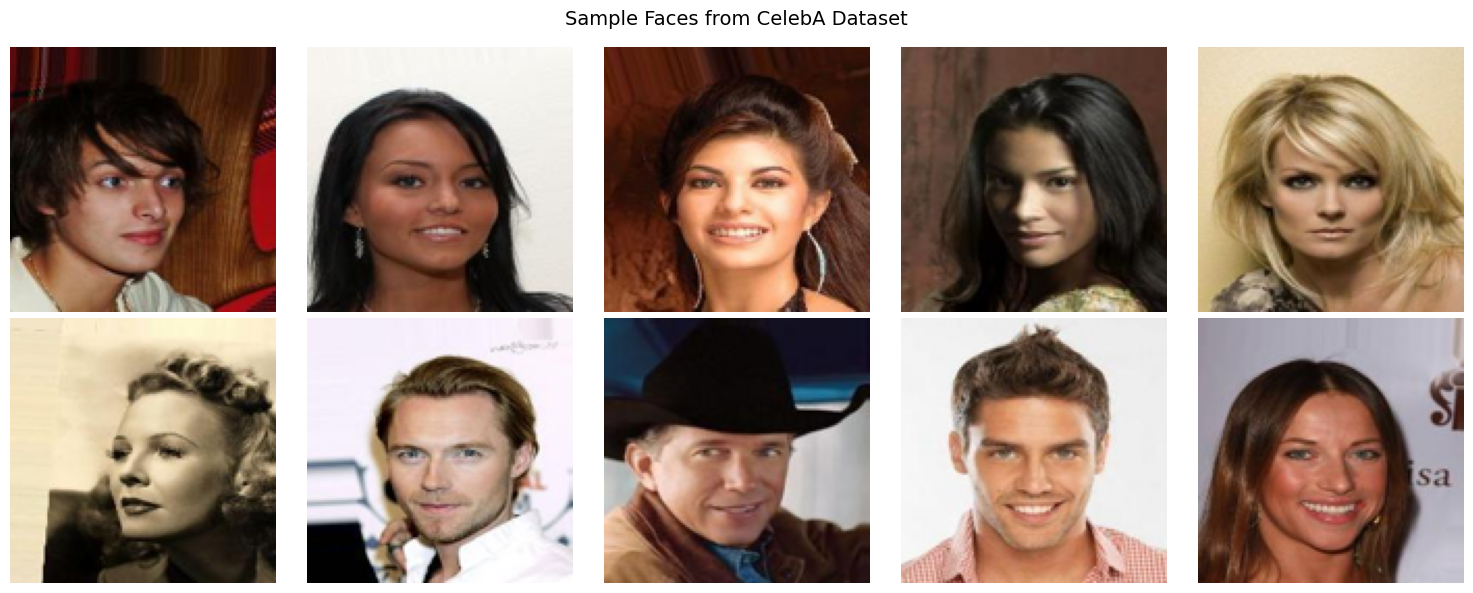

In [4]:
# Load the prepared dataset
data = load(COMPRESSED_FILE)
faces = data['arr_0']
print('Loaded dataset shape: ', faces.shape)

# Display sample faces
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(faces[i])
    ax.axis('off')
plt.suptitle('Sample Faces from CelebA Dataset', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Building Essential Custom Layers and Functions

ProGAN introduces several custom components:

- **Pixel Normalization**: Normalizes feature vector in each pixel to unit length (replaces batch normalization)
- **Minibatch Standard Deviation**: Encourages generator diversity by computing statistics across mini-batches
- **Weighted Sum (Fade-In)**: Smoothly blends new higher-resolution layers using formula: `(1-α) × UpsampledLayer + α × OutputLayer`
- **Wasserstein Loss**: L(y_true, y_pred) = mean(y_true * y_pred)

In [3]:
# Pixel-wise feature vector normalization layer
class PixelNormalization(Layer):
    def __init__(self, **kwargs):
        super(PixelNormalization, self).__init__(**kwargs)

    def call(self, inputs):
        values = inputs**2.0
        mean_values = backend.mean(values, axis=-1, keepdims=True)
        mean_values += 1.0e-8
        l2 = backend.sqrt(mean_values)
        normalized = inputs / l2
        return normalized

    def compute_output_shape(self, input_shape):
        return input_shape


# Mini-batch standard deviation layer
class MinibatchStdev(Layer):
    def __init__(self, **kwargs):
        super(MinibatchStdev, self).__init__(**kwargs)

    def call(self, inputs):
        mean = backend.mean(inputs, axis=0, keepdims=True)
        squ_diffs = backend.square(inputs - mean)
        mean_sq_diff = backend.mean(squ_diffs, axis=0, keepdims=True)
        mean_sq_diff += 1e-8
        stdev = backend.sqrt(mean_sq_diff)
        mean_pix = backend.mean(stdev, keepdims=True)
        shape = backend.shape(inputs)
        output = backend.tile(mean_pix, (shape[0], shape[1], shape[2], 1))
        combined = backend.concatenate([inputs, output], axis=-1)
        return combined

    def compute_output_shape(self, input_shape):
        input_shape = list(input_shape)
        input_shape[-1] += 1
        return tuple(input_shape)


# Weighted sum output for fade-in
class WeightedSum(Add):
    def __init__(self, alpha=0.0, **kwargs):
        super(WeightedSum, self).__init__(**kwargs)
        self.alpha = backend.variable(alpha, name='ws_alpha')

    def _merge_function(self, inputs):
        assert (len(inputs) == 2)
        output = ((1.0 - self.alpha) * inputs[0]) + (self.alpha * inputs[1])
        return output


# Wasserstein loss
def wasserstein_loss(y_true, y_pred):
    return backend.mean(y_true * y_pred)

print('Custom layers and loss function defined.')

Custom layers and loss function defined.


### 3.1 Utility Functions

Helper functions for loading data, generating real/fake samples, updating fade-in alpha, and scaling the dataset.

In [4]:
# Load dataset
def load_real_samples(filename):
    data = load(filename)
    X = data['arr_0']
    X = X.astype('float32')
    # Scale to [-1, 1]
    X = (X - 127.5) / 127.5
    return X

# Select real samples
def generate_real_samples(dataset, n_samples):
    ix = randint(0, dataset.shape[0], n_samples)
    X = dataset[ix]
    y = ones((n_samples, 1))
    return X, y

# Generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples):
    x_input = randn(latent_dim * n_samples)
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

# Use the generator to generate n fake examples, with class labels
def generate_fake_samples(generator, latent_dim, n_samples):
    x_input = generate_latent_points(latent_dim, n_samples)
    X = generator.predict(x_input, verbose=0)
    y = -ones((n_samples, 1))
    return X, y

# Update the alpha value on each instance of WeightedSum
def update_fadein(models, step, n_steps):
    alpha = step / float(n_steps - 1)
    for model in models:
        for layer in model.layers:
            if isinstance(layer, WeightedSum):
                backend.set_value(layer.alpha, alpha)

# Scale images to preferred size
def scale_dataset(images, new_shape):
    images_list = list()
    for image in images:
        new_image = resize(image, new_shape, 0)
        images_list.append(new_image)
    return asarray(images_list)

print('Utility functions defined.')

Utility functions defined.


## 4. Generator Network

The generator starts with a latent vector and produces a 4×4 image. We then progressively add upsampling + convolutional blocks to increase resolution. Each block uses:
- **UpSampling2D** to double spatial dimensions
- **Conv2D** (128 filters, 3×3) with Pixel Normalization and LeakyReLU
- **1×1 Conv2D** to map to RGB output
- **WeightedSum** for fade-in blending between old and new paths

Instead of the equalized learning rate from the paper, we use Gaussian random initialization with max norm weight constraint.

In [5]:
# Adding a generator block
def add_generator_block(old_model):
    init = RandomNormal(stddev=0.02)
    const = max_norm(1.0)
    block_end = old_model.layers[-2].output

    # Upsample, and define new block
    upsampling = UpSampling2D()(block_end)
    g = Conv2D(128, (3,3), padding='same', kernel_initializer=init, kernel_constraint=const)(upsampling)
    g = PixelNormalization()(g)
    g = LeakyReLU(alpha=0.2)(g)
    g = Conv2D(128, (3,3), padding='same', kernel_initializer=init, kernel_constraint=const)(g)
    g = PixelNormalization()(g)
    g = LeakyReLU(alpha=0.2)(g)

    # New output (straight-through model)
    out_image = Conv2D(3, (1,1), padding='same', kernel_initializer=init, kernel_constraint=const)(g)
    model1 = Model(old_model.input, out_image)

    # Fade-in model
    out_old = old_model.layers[-1]
    out_image2 = out_old(upsampling)
    merged = WeightedSum()([out_image2, out_image])
    model2 = Model(old_model.input, merged)

    return [model1, model2]


# Define generator models for each resolution level
def define_generator(latent_dim, n_blocks, in_dim=4):
    init = RandomNormal(stddev=0.02)
    const = max_norm(1.0)
    model_list = list()

    in_latent = Input(shape=(latent_dim,))
    g = Dense(128 * in_dim * in_dim, kernel_initializer=init, kernel_constraint=const)(in_latent)
    g = Reshape((in_dim, in_dim, 128))(g)

    # Conv 4x4, input block
    g = Conv2D(128, (3,3), padding='same', kernel_initializer=init, kernel_constraint=const)(g)
    g = PixelNormalization()(g)
    g = LeakyReLU(alpha=0.2)(g)

    # Conv 3x3
    g = Conv2D(128, (3,3), padding='same', kernel_initializer=init, kernel_constraint=const)(g)
    g = PixelNormalization()(g)
    g = LeakyReLU(alpha=0.2)(g)

    # Conv 1x1, output block
    out_image = Conv2D(3, (1,1), padding='same', kernel_initializer=init, kernel_constraint=const)(g)
    model = Model(in_latent, out_image)
    model_list.append([model, model])

    # Progressively add blocks
    for i in range(1, n_blocks):
        old_model = model_list[i - 1][0]
        models = add_generator_block(old_model)
        model_list.append(models)

    return model_list

print('Generator network defined.')

Generator network defined.


## 5. Discriminator Network

The discriminator reverses the generator's architecture:
- Takes an RGB image input
- Applies Conv2D blocks with AveragePooling2D for downsampling
- Uses **MinibatchStdev** at the output block to encourage variety
- Outputs a single value (real/fake prediction)
- Uses **WeightedSum** for fade-in of new higher-resolution blocks

In [6]:
# Adding a discriminator block
def add_discriminator_block(old_model, n_input_layers=3):
    init = RandomNormal(stddev=0.02)
    const = max_norm(1.0)
    in_shape = list(old_model.input.shape)

    # Define new input shape as double the size
    input_shape = (in_shape[-2]*2, in_shape[-2]*2, in_shape[-1])
    in_image = Input(shape=input_shape)

    # Define new input processing layer
    d = Conv2D(128, (1,1), padding='same', kernel_initializer=init, kernel_constraint=const)(in_image)
    d = LeakyReLU(alpha=0.2)(d)

    # Define new block
    d = Conv2D(128, (3,3), padding='same', kernel_initializer=init, kernel_constraint=const)(d)
    d = LeakyReLU(alpha=0.2)(d)
    d = Conv2D(128, (3,3), padding='same', kernel_initializer=init, kernel_constraint=const)(d)
    d = LeakyReLU(alpha=0.2)(d)
    d = AveragePooling2D()(d)
    block_new = d

    # Skip the input, 1x1 and activation for the old model
    for i in range(n_input_layers, len(old_model.layers)):
        d = old_model.layers[i](d)
    model1 = Model(in_image, d)
    model1.compile(loss=wasserstein_loss, optimizer=Adam(learning_rate=0.001, beta_1=0, beta_2=0.99, epsilon=10e-8))

    # Fade-in model
    downsample = AveragePooling2D()(in_image)
    block_old = old_model.layers[1](downsample)
    block_old = old_model.layers[2](block_old)
    d = WeightedSum()([block_old, block_new])

    for i in range(n_input_layers, len(old_model.layers)):
        d = old_model.layers[i](d)
    model2 = Model(in_image, d)
    model2.compile(loss=wasserstein_loss, optimizer=Adam(learning_rate=0.001, beta_1=0, beta_2=0.99, epsilon=10e-8))

    return [model1, model2]


# Define the discriminator models for each image resolution
def define_discriminator(n_blocks, input_shape=(4,4,3)):
    init = RandomNormal(stddev=0.02)
    const = max_norm(1.0)
    model_list = list()

    in_image = Input(shape=input_shape)
    d = Conv2D(128, (1,1), padding='same', kernel_initializer=init, kernel_constraint=const)(in_image)
    d = LeakyReLU(alpha=0.2)(d)

    # Minibatch stdev
    d = MinibatchStdev()(d)

    d = Conv2D(128, (3,3), padding='same', kernel_initializer=init, kernel_constraint=const)(d)
    d = LeakyReLU(alpha=0.2)(d)
    d = Conv2D(128, (4,4), padding='same', kernel_initializer=init, kernel_constraint=const)(d)
    d = LeakyReLU(alpha=0.2)(d)

    d = Flatten()(d)
    out_class = Dense(1)(d)

    model = Model(in_image, out_class)
    model.compile(loss=wasserstein_loss, optimizer=Adam(learning_rate=0.001, beta_1=0, beta_2=0.99, epsilon=10e-8))
    model_list.append([model, model])

    # Progressively add blocks
    for i in range(1, n_blocks):
        old_model = model_list[i - 1][0]
        models = add_discriminator_block(old_model)
        model_list.append(models)

    return model_list

print('Discriminator network defined.')

Discriminator network defined.


## 6. Composite ProGAN Model

The composite model combines the generator and discriminator for training the generator via the discriminator's error signal. We create both straight-through and fade-in composite models at each resolution level.

In [7]:
# Define composite models for training generators via discriminators
def define_composite(discriminators, generators):
    model_list = list()
    for i in range(len(discriminators)):
        g_models, d_models = generators[i], discriminators[i]

        # Straight-through model
        d_models[0].trainable = False
        model1 = Sequential()
        model1.add(g_models[0])
        model1.add(d_models[0])
        model1.compile(loss=wasserstein_loss, optimizer=Adam(learning_rate=0.001, beta_1=0, beta_2=0.99, epsilon=10e-8))

        # Fade-in model
        d_models[1].trainable = False
        model2 = Sequential()
        model2.add(g_models[1])
        model2.add(d_models[1])
        model2.compile(loss=wasserstein_loss, optimizer=Adam(learning_rate=0.001, beta_1=0, beta_2=0.99, epsilon=10e-8))

        model_list.append([model1, model2])
    return model_list

print('Composite model function defined.')

Composite model function defined.


## 7. Training Functions

### Training Strategy
- **Progressive training**: Start at 4×4, then grow to 8×8 → 16×16 → 32×32 → 64×64 → 128×128
- **Fade-in**: New layers are gradually blended using alpha interpolation
- **Batch sizes**: Larger for small resolutions, smaller for larger resolutions
- **Epochs**: Fewer for small resolutions, more for larger resolutions

The training alternates between:
1. Train discriminator on real and fake samples
2. Train generator via discriminator's error

In [8]:
# Generate samples and save as a plot and save the model
def summarize_performance(status, g_model, latent_dim, n_samples=25):
    gen_shape = g_model.output_shape
    name = '%03dx%03d-%s' % (gen_shape[1], gen_shape[2], status)

    X, _ = generate_fake_samples(g_model, latent_dim, n_samples)
    X = (X - X.min()) / (X.max() - X.min())

    square = int(sqrt(n_samples))
    fig, axes = plt.subplots(square, square, figsize=(10, 10))
    for i in range(n_samples):
        row = i // square
        col = i % square
        axes[row, col].imshow(X[i])
        axes[row, col].axis('off')
    plt.suptitle(f'Generated Faces - {name}', fontsize=14)

    # Save plot to output folder
    os.makedirs('output', exist_ok=True)
    filename1 = os.path.join('output', 'plot_%s.png' % name)
    plt.savefig(filename1)
    plt.show()
    plt.close()

    # Save model
    os.makedirs('models', exist_ok=True)
    filename2 = os.path.join('models', 'model_%s.h5' % name)
    g_model.save(filename2)
    print('>Saved: %s and %s' % (filename1, filename2))


# Train a generator and discriminator for a number of epochs
def train_epochs(g_model, d_model, gan_model, dataset, n_epochs, n_batch, fadein=False):
    bat_per_epo = int(dataset.shape[0] / n_batch)
    n_steps = bat_per_epo * n_epochs
    half_batch = int(n_batch / 2)

    for i in range(n_steps):
        # Update alpha for all WeightedSum layers when fading in new blocks
        if fadein:
            update_fadein([g_model, d_model, gan_model], i, n_steps)

        # Prepare real and fake samples
        X_real, y_real = generate_real_samples(dataset, half_batch)
        X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)

        # Update discriminator model
        d_loss1 = d_model.train_on_batch(X_real, y_real)
        d_loss2 = d_model.train_on_batch(X_fake, y_fake)

        # Update the generator via the discriminator's error
        z_input = generate_latent_points(latent_dim, n_batch)
        y_real2 = ones((n_batch, 1))
        g_loss = gan_model.train_on_batch(z_input, y_real2)

        # Summarize loss on this batch (print every 100 steps)
        if (i + 1) % 100 == 0 or i == 0:
            print('>%d/%d, d1=%.3f, d2=%.3f g=%.3f' % (i+1, n_steps, d_loss1, d_loss2, g_loss))


# Main training loop with progressive growing
def train(g_models, d_models, gan_models, dataset, latent_dim, e_norm, e_fadein, n_batch):
    # Train the base model (4x4)
    g_normal, d_normal, gan_normal = g_models[0][0], d_models[0][0], gan_models[0][0]
    gen_shape = g_normal.output_shape
    scaled_data = scale_dataset(dataset, gen_shape[1:])
    print(f'Scaled Data: {scaled_data.shape}')

    # Train normal or straight-through models
    train_epochs(g_normal, d_normal, gan_normal, scaled_data, e_norm[0], n_batch[0])
    summarize_performance('tuned', g_normal, latent_dim)

    # Process each level of growth
    for i in range(1, len(g_models)):
        # Retrieve models for this level of growth
        [g_normal, g_fadein] = g_models[i]
        [d_normal, d_fadein] = d_models[i]
        [gan_normal, gan_fadein] = gan_models[i]

        # Scale dataset to appropriate size
        gen_shape = g_normal.output_shape
        scaled_data = scale_dataset(dataset, gen_shape[1:])
        print(f'Scaled Data: {scaled_data.shape}')

        # Train fade-in models for next level of growth
        train_epochs(g_fadein, d_fadein, gan_fadein, scaled_data, e_fadein[i], n_batch[i], True)
        summarize_performance('faded', g_fadein, latent_dim)

        # Train normal or straight-through models
        train_epochs(g_normal, d_normal, gan_normal, scaled_data, e_norm[i], n_batch[i])
        summarize_performance('tuned', g_normal, latent_dim)

print('Training functions defined.')

Training functions defined.


## 8. Initialize and Train ProGAN

We configure the ProGAN with:
- **6 growth phases**: 4×4 → 8×8 → 16×16 → 32×32 → 64×64 → 128×128
- **Latent dimension**: 100
- **Batch sizes**: [16, 16, 16, 8, 4, 4] (larger for small resolutions)
- **Epochs**: [5, 8, 8, 10, 10, 10] (more for larger resolutions)

In [9]:
# Number of growth phases: 6 blocks == [4, 8, 16, 32, 64, 128]
n_blocks = 6
latent_dim = 100

# Define models
print('Defining discriminator models...')
d_models = define_discriminator(n_blocks)
print('Defining generator models...')
g_models = define_generator(latent_dim, n_blocks)
print('Defining composite GAN models...')
gan_models = define_composite(d_models, g_models)

# Print model summaries for each resolution
for i, (g_pair, d_pair) in enumerate(zip(g_models, d_models)):
    res = 4 * (2 ** i)
    print(f'\nResolution {res}x{res}:')
    print(f'  Generator params: {g_pair[0].count_params():,}')
    print(f'  Discriminator params: {d_pair[0].count_params():,}')

Defining discriminator models...

Defining generator models...
Defining composite GAN models...

Resolution 4x4:
  Generator params: 502,403
  Discriminator params: 413,569

Resolution 8x8:
  Generator params: 797,571
  Discriminator params: 708,737

Resolution 16x16:
  Generator params: 1,092,739
  Discriminator params: 1,003,905

Resolution 32x32:
  Generator params: 1,387,907
  Discriminator params: 1,299,073

Resolution 64x64:
  Generator params: 1,683,075
  Discriminator params: 1,594,241

Resolution 128x128:
  Generator params: 1,978,243
  Discriminator params: 1,889,409


Loaded dataset: (10000, 128, 128, 3)

=== Starting ProGAN Progressive Training ===
Growth phases: 6 blocks
Resolutions: [4, 8, 16, 32, 64, 128]
Batch sizes: [16, 16, 16, 8, 4, 4]
Epochs per phase: [5, 8, 8, 10, 10, 10]
Scaled Data: (10000, 4, 4, 3)

>1/3125, d1=0.002, d2=0.016 g=0.006
>100/3125, d1=-0.001, d2=0.002 g=-0.000
>200/3125, d1=-0.001, d2=0.005 g=0.001
>300/3125, d1=0.000, d2=0.005 g=0.002
>400/3125, d1=-0.001, d2=0.004 g=-0.001
>500/3125, d1=-0.006, d2=0.007 g=-0.003
>600/3125, d1=-0.001, d2=0.005 g=-0.001
>700/3125, d1=0.001, d2=0.002 g=0.001
>800/3125, d1=-0.004, d2=0.002 g=0.002
>900/3125, d1=0.004, d2=0.007 g=0.000
>1000/3125, d1=-0.002, d2=0.003 g=-0.001
>1100/3125, d1=-0.001, d2=0.006 g=-0.001
>1200/3125, d1=0.002, d2=0.002 g=0.001
>1300/3125, d1=-0.012, d2=0.007 g=-0.004
>1400/3125, d1=0.000, d2=0.003 g=0.000
>1500/3125, d1=-0.001, d2=0.004 g=0.001
>1600/3125, d1=-0.001, d2=0.004 g=-0.000
>1700/3125, d1=-0.000, d2=0.003 g=0.001
>1800/3125, d1=-0.000, d2=0.002 g=-0.000

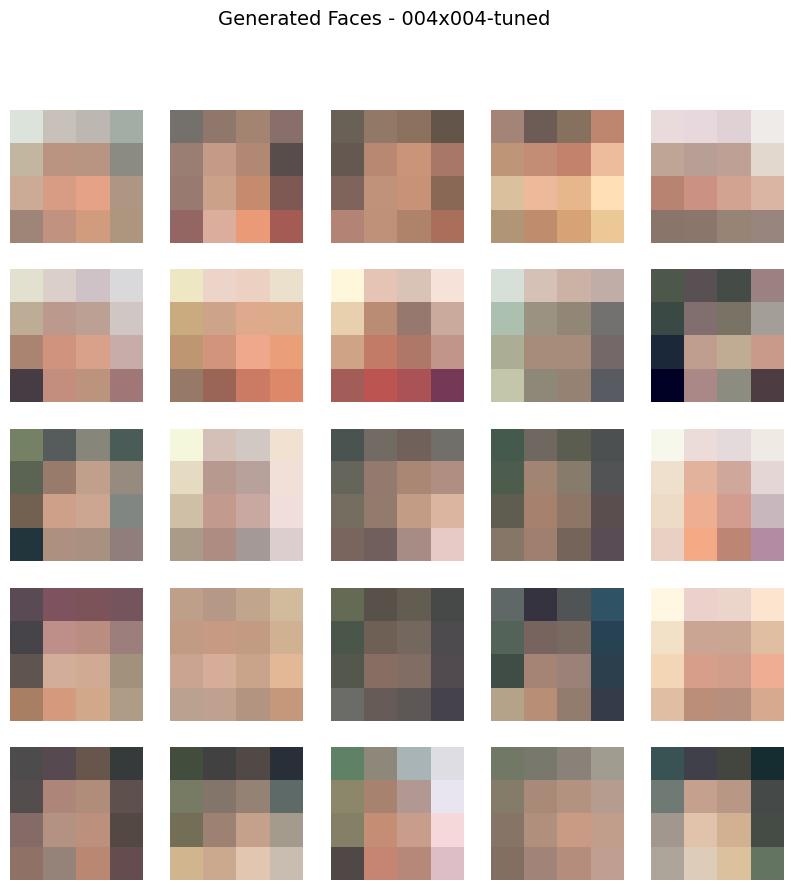

>Saved: output\plot_004x004-tuned.png and models\model_004x004-tuned.h5
Scaled Data: (10000, 8, 8, 3)
>1/5000, d1=-0.001, d2=0.004 g=0.007
>100/5000, d1=-3.441, d2=7.775 g=-5.638
>200/5000, d1=-0.013, d2=0.609 g=0.257
>300/5000, d1=-0.059, d2=0.152 g=-0.069
>400/5000, d1=-0.018, d2=0.138 g=-0.073
>500/5000, d1=-0.162, d2=0.144 g=-0.025
>600/5000, d1=-0.037, d2=0.035 g=-0.044
>700/5000, d1=-0.019, d2=0.010 g=0.010
>800/5000, d1=-0.015, d2=0.012 g=0.006
>900/5000, d1=-0.028, d2=0.017 g=-0.005
>1000/5000, d1=-0.012, d2=0.019 g=0.009
>1100/5000, d1=0.000, d2=0.036 g=0.003
>1200/5000, d1=-0.011, d2=0.024 g=0.001
>1300/5000, d1=-0.006, d2=0.013 g=-0.002
>1400/5000, d1=-0.005, d2=0.017 g=-0.005
>1500/5000, d1=0.002, d2=0.008 g=-0.000
>1600/5000, d1=-0.004, d2=0.010 g=-0.002
>1700/5000, d1=-0.009, d2=0.018 g=-0.007
>1800/5000, d1=-0.002, d2=0.009 g=-0.003
>1900/5000, d1=-0.013, d2=0.044 g=-0.006
>2000/5000, d1=-0.004, d2=0.047 g=-0.007
>2100/5000, d1=-0.002, d2=0.007 g=-0.000
>2200/5000, d1=-0

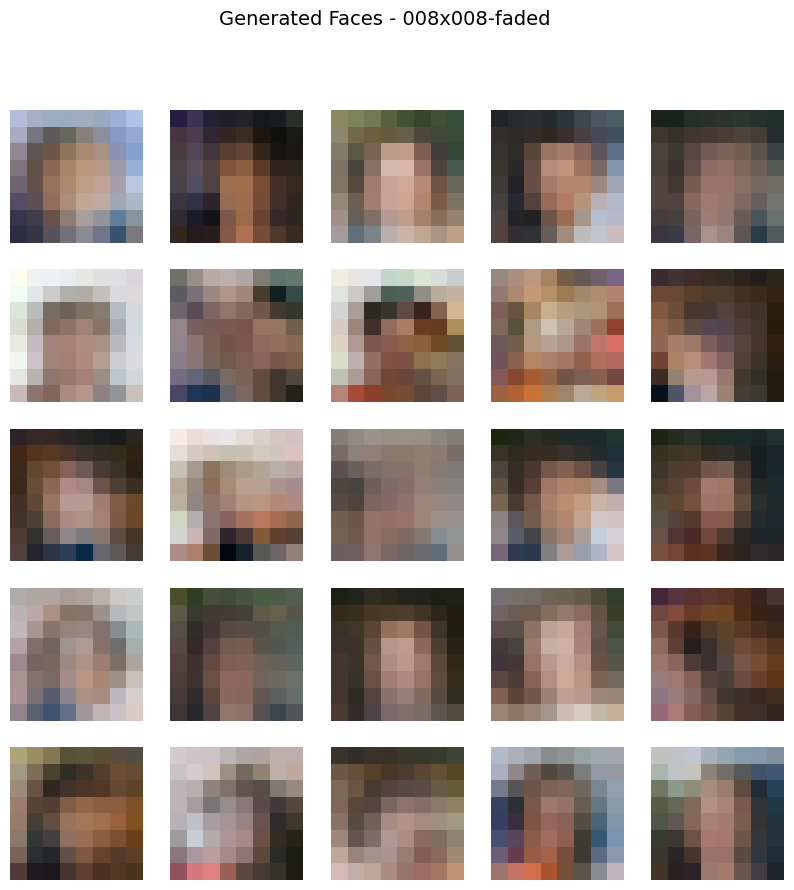

>Saved: output\plot_008x008-faded.png and models\model_008x008-faded.h5
>1/5000, d1=0.056, d2=0.144 g=0.096
>100/5000, d1=-0.398, d2=0.103 g=-0.034
>200/5000, d1=-0.050, d2=0.137 g=0.152
>300/5000, d1=-0.331, d2=-0.067 g=0.620
>400/5000, d1=0.171, d2=0.640 g=-0.768
>500/5000, d1=-0.740, d2=0.923 g=-0.328
>600/5000, d1=-0.329, d2=0.587 g=-0.295
>700/5000, d1=-0.339, d2=0.400 g=-0.362
>800/5000, d1=-0.059, d2=0.042 g=0.092
>900/5000, d1=0.015, d2=0.097 g=0.148
>1000/5000, d1=-1.047, d2=1.184 g=-0.196
>1100/5000, d1=0.010, d2=0.910 g=-0.499
>1200/5000, d1=-0.288, d2=0.815 g=0.098
>1300/5000, d1=-1.966, d2=0.244 g=0.015
>1400/5000, d1=-1.057, d2=0.898 g=-0.581
>1500/5000, d1=0.306, d2=-1.144 g=0.838
>1600/5000, d1=-3.113, d2=3.865 g=-1.115
>1700/5000, d1=0.443, d2=2.072 g=-1.491
>1800/5000, d1=-3.719, d2=0.854 g=3.873
>1900/5000, d1=-1.399, d2=2.958 g=-2.353
>2000/5000, d1=-3.638, d2=5.086 g=-0.172
>2100/5000, d1=-1.424, d2=1.724 g=-1.114
>2200/5000, d1=-0.221, d2=1.212 g=-0.593
>2300/5000

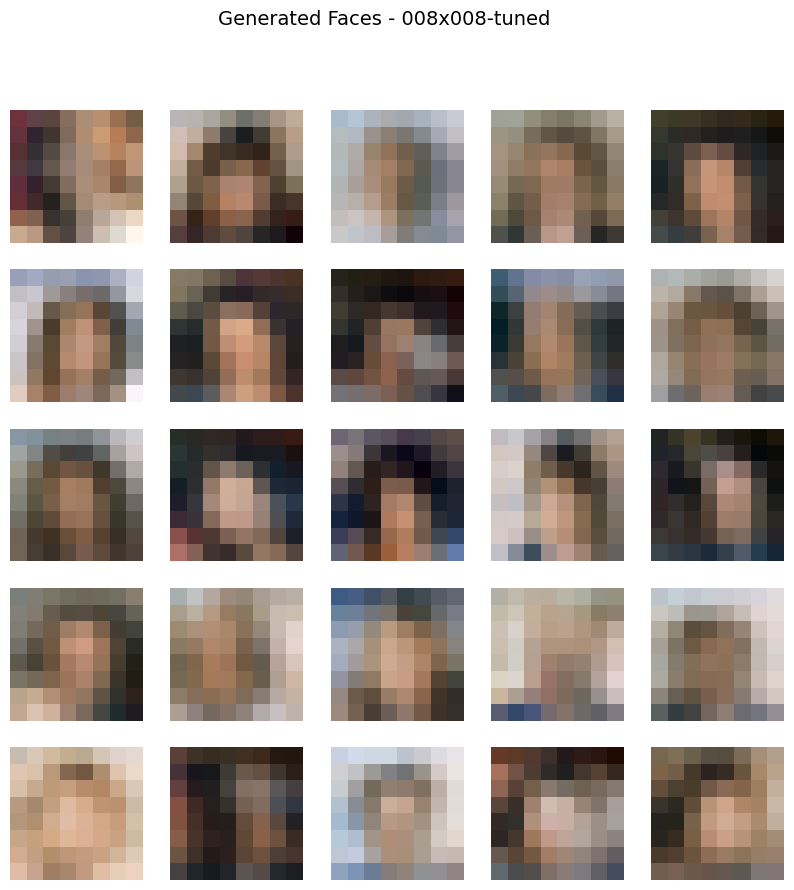

>Saved: output\plot_008x008-tuned.png and models\model_008x008-tuned.h5
Scaled Data: (10000, 16, 16, 3)
>1/5000, d1=-4.821, d2=-2.920 g=-1.364
>100/5000, d1=-6.646, d2=17.442 g=-1.408
>200/5000, d1=-9.929, d2=12.725 g=-0.937
>300/5000, d1=74920544.000, d2=-107065600.000 g=106717024.000
>400/5000, d1=65561560.000, d2=-20194746.000 g=19613180.000
>500/5000, d1=3825795.500, d2=-23782170.000 g=29072980.000
>600/5000, d1=-5091862.000, d2=12446741.000 g=-5333220.500
>700/5000, d1=2032544.500, d2=-244775.672 g=438911.656
>800/5000, d1=-79968.094, d2=166525.156 g=-47749.160
>900/5000, d1=-463634.875, d2=695014.250 g=-294647.625
>1000/5000, d1=365661696.000, d2=-600295552.000 g=694973824.000
>1100/5000, d1=98044240.000, d2=49477276.000 g=-53085956.000
>1200/5000, d1=16758880.000, d2=-10045886.000 g=12748024.000
>1300/5000, d1=-2605642.750, d2=5609653.500 g=-525309.375
>1400/5000, d1=-4307106.500, d2=22718584.000 g=-9753140.000
>1500/5000, d1=-6480961.000, d2=5206003.500 g=-3841439.750
>1600/500

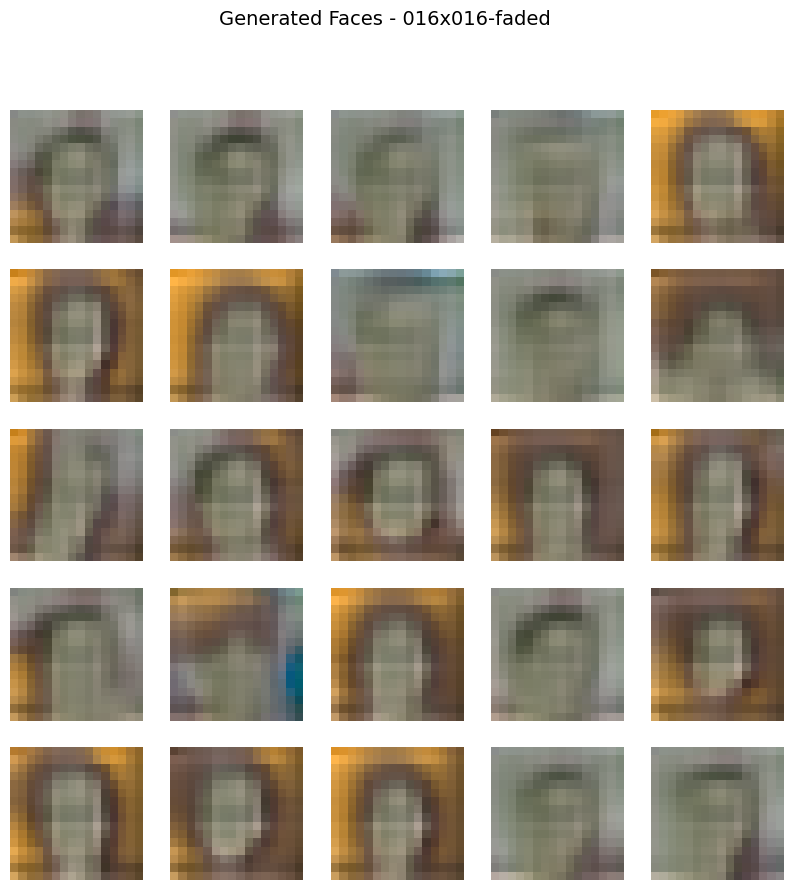

>Saved: output\plot_016x016-faded.png and models\model_016x016-faded.h5
>1/5000, d1=-858385.688, d2=5986942.500 g=-2278724.500
>100/5000, d1=-494017.031, d2=2415735.750 g=915296.438
>200/5000, d1=-776068.625, d2=2328200.500 g=-598406.750
>300/5000, d1=1828777.750, d2=-979283.438 g=527375.500
>400/5000, d1=-191766.922, d2=273299.750 g=-384389.781
>500/5000, d1=939028.250, d2=-417785.375 g=1261126.250
>600/5000, d1=1109886.000, d2=2369169.000 g=2531534.750
>700/5000, d1=2238724.000, d2=675143.125 g=761058.375
>800/5000, d1=2027337.500, d2=807023.750 g=1071587.750
>900/5000, d1=9175207.000, d2=-2820304.000 g=14196798.000
>1000/5000, d1=992.688, d2=516708.562 g=-4841218.500
>1100/5000, d1=3911401.250, d2=-1277335.500 g=3472344.500
>1200/5000, d1=4409247.000, d2=-1999780.250 g=4763235.500
>1300/5000, d1=2118537.750, d2=-341080.781 g=2052047.000
>1400/5000, d1=286784.500, d2=870514.625 g=1843405.250
>1500/5000, d1=-2112121.250, d2=11264419.000 g=4670206.500
>1600/5000, d1=942641.750, d2=-494

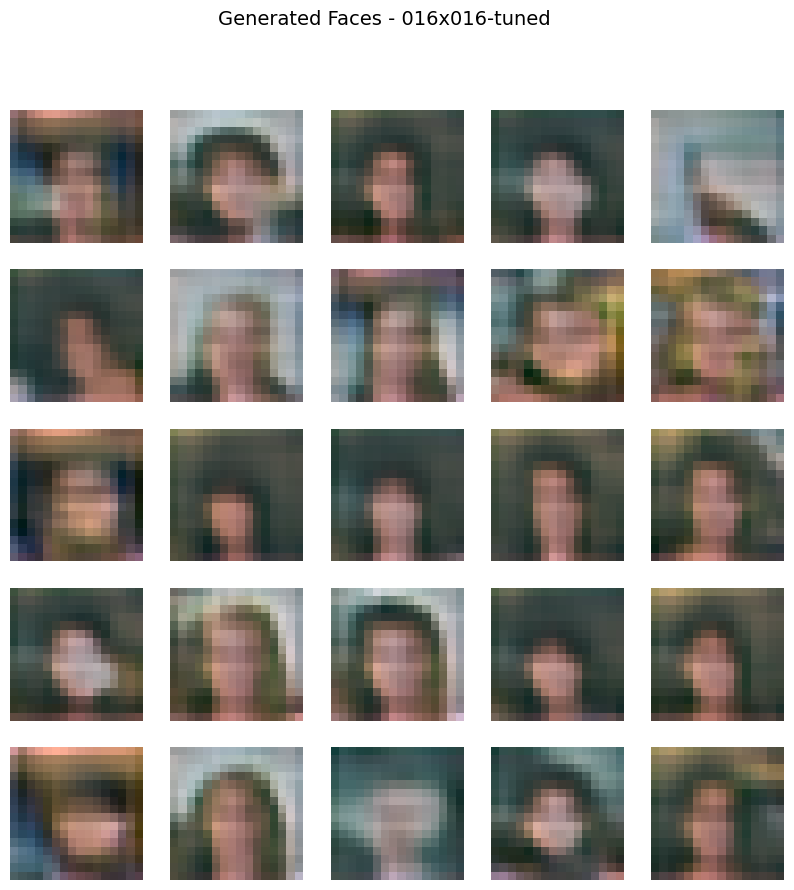

>Saved: output\plot_016x016-tuned.png and models\model_016x016-tuned.h5
Scaled Data: (10000, 32, 32, 3)
>1/12500, d1=-1081583.500, d2=385706.312 g=-232681.500
>100/12500, d1=-1070960.750, d2=-907611.500 g=2367103.500
>200/12500, d1=977524.750, d2=-769171.062 g=1424265.750
>300/12500, d1=-86070.609, d2=288862.812 g=265437.094
>400/12500, d1=287540.250, d2=383166.219 g=44640.875
>500/12500, d1=366179.750, d2=639921.625 g=1202746.250
>600/12500, d1=-1705483.000, d2=2331446.000 g=-527268.688
>700/12500, d1=-13192810.000, d2=54703464.000 g=-2334416.500
>800/12500, d1=428965.375, d2=1433173.750 g=-1082026.000
>900/12500, d1=810706.500, d2=113181.742 g=877120.375
>1000/12500, d1=425356.062, d2=1258533.250 g=311057.219
>1100/12500, d1=-1048800.250, d2=409957.875 g=634692.000
>1200/12500, d1=-147603.156, d2=818200.500 g=-569825.750
>1300/12500, d1=218228.203, d2=-26374.875 g=537113.375
>1400/12500, d1=-679960.875, d2=-211555.984 g=829517.438
>1500/12500, d1=-1816525.000, d2=-1299662.375 g=-3951

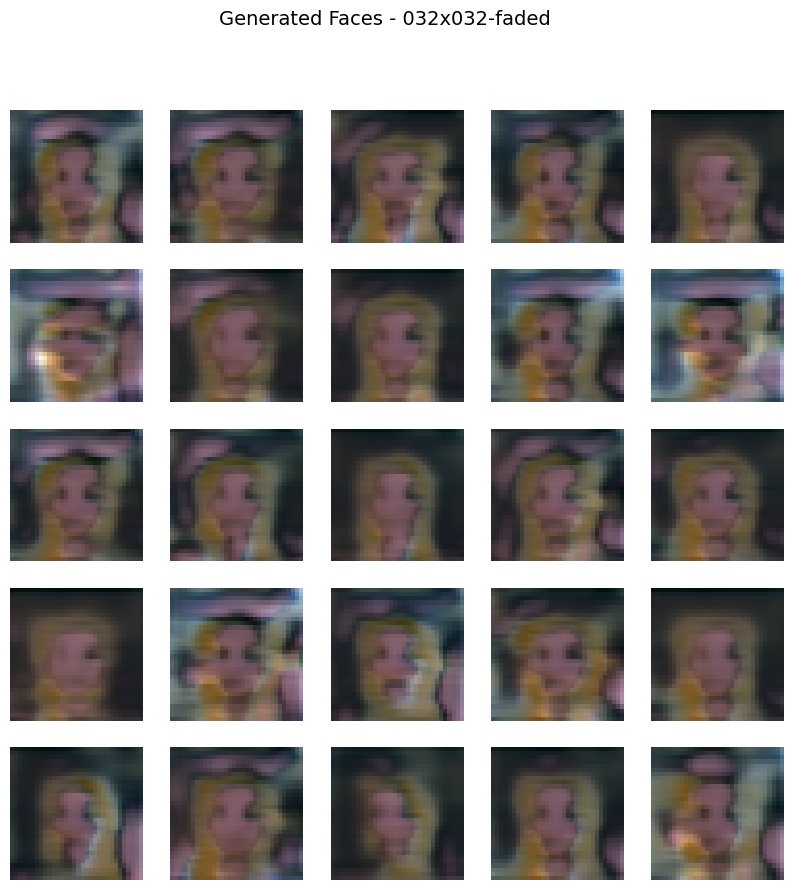

>Saved: output\plot_032x032-faded.png and models\model_032x032-faded.h5
>1/12500, d1=173515456.000, d2=1438343168.000 g=2001439232.000
>100/12500, d1=-3537948672.000, d2=-498083072.000 g=2263832576.000
>200/12500, d1=-748592000.000, d2=605412224.000 g=892657152.000
>300/12500, d1=-3332499456.000, d2=5823455232.000 g=-708670912.000
>400/12500, d1=300343168.000, d2=110603856.000 g=388149088.000
>500/12500, d1=1618041472.000, d2=3341234688.000 g=-2104907008.000
>600/12500, d1=-3881142272.000, d2=10116184064.000 g=-3907703040.000
>700/12500, d1=990863552.000, d2=601888640.000 g=1588486784.000
>800/12500, d1=963217536.000, d2=-14055096.000 g=1722876544.000
>900/12500, d1=-4323834368.000, d2=512890304.000 g=5014604288.000
>1000/12500, d1=1019810432.000, d2=-863914304.000 g=2692196096.000
>1100/12500, d1=805067008.000, d2=2284856576.000 g=3612271104.000
>1200/12500, d1=-993999360.000, d2=-3231740416.000 g=4645207040.000
>1300/12500, d1=195504640.000, d2=5977887744.000 g=-1471355904.000
>1400/

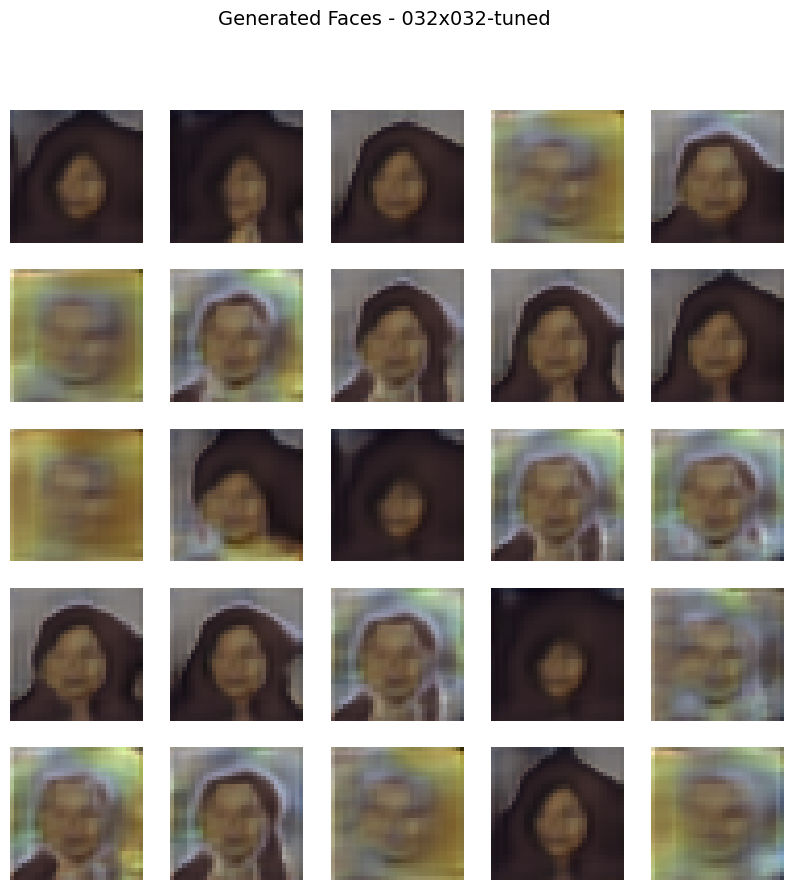

>Saved: output\plot_032x032-tuned.png and models\model_032x032-tuned.h5
Scaled Data: (10000, 64, 64, 3)
>1/25000, d1=-228327145472.000, d2=245792096256.000 g=6960830464.000
>100/25000, d1=237635272704.000, d2=1737766993920.000 g=129635352576.000
>200/25000, d1=120891858944.000, d2=45746094080.000 g=394513317888.000
>300/25000, d1=-1007375220736.000, d2=1341503832064.000 g=-1378275819520.000
>400/25000, d1=-283731099648.000, d2=313778176000.000 g=-289324630016.000
>500/25000, d1=-496996450304.000, d2=494408499200.000 g=-38515400704.000
>600/25000, d1=-281562775552.000, d2=192319127552.000 g=13415317504.000
>700/25000, d1=-400124346368.000, d2=78261723136.000 g=32027049984.000
>800/25000, d1=-571877097472.000, d2=282765623296.000 g=-286237720576.000
>900/25000, d1=-4753957322752.000, d2=-109139025920.000 g=212914143232.000
>1000/25000, d1=-1166302511104.000, d2=383179784192.000 g=308907671552.000
>1100/25000, d1=-825913376768.000, d2=405979889664.000 g=1030406406144.000
>1200/25000, d1=-

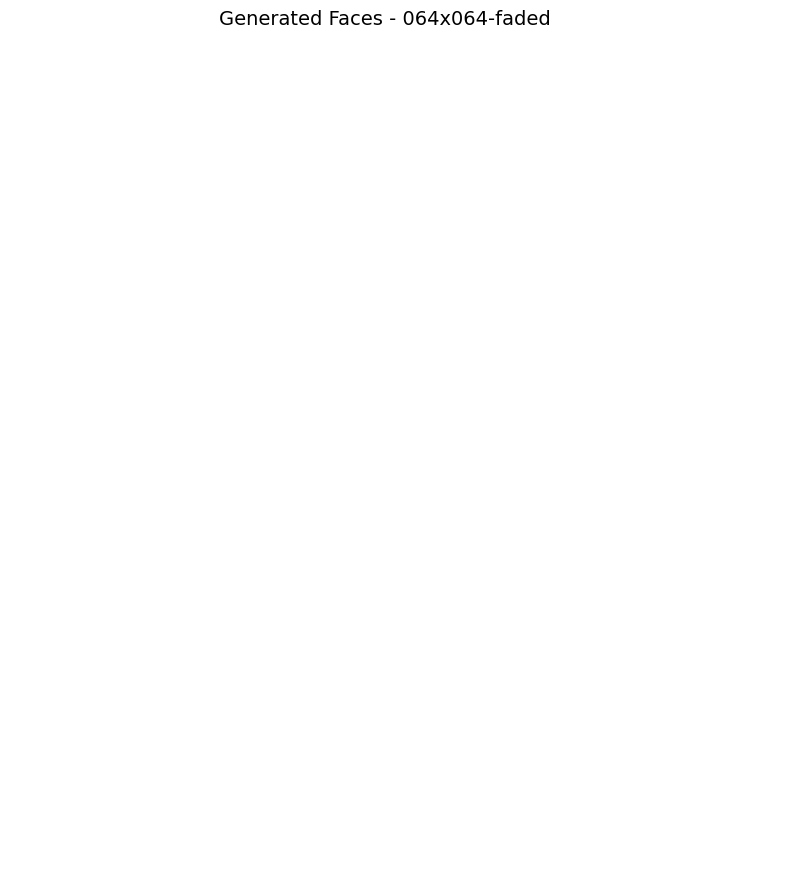

>Saved: output\plot_064x064-faded.png and models\model_064x064-faded.h5
>1/25000, d1=nan, d2=nan g=nan
>100/25000, d1=nan, d2=nan g=nan
>200/25000, d1=nan, d2=nan g=nan
>300/25000, d1=nan, d2=nan g=nan
>400/25000, d1=nan, d2=nan g=nan
>500/25000, d1=nan, d2=nan g=nan
>600/25000, d1=nan, d2=nan g=nan
>700/25000, d1=nan, d2=nan g=nan
>800/25000, d1=nan, d2=nan g=nan
>900/25000, d1=nan, d2=nan g=nan
>1000/25000, d1=nan, d2=nan g=nan
>1100/25000, d1=nan, d2=nan g=nan
>1200/25000, d1=nan, d2=nan g=nan
>1300/25000, d1=nan, d2=nan g=nan
>1400/25000, d1=nan, d2=nan g=nan
>1500/25000, d1=nan, d2=nan g=nan
>1600/25000, d1=nan, d2=nan g=nan
>1700/25000, d1=nan, d2=nan g=nan
>1800/25000, d1=nan, d2=nan g=nan
>1900/25000, d1=nan, d2=nan g=nan
>2000/25000, d1=nan, d2=nan g=nan
>2100/25000, d1=nan, d2=nan g=nan
>2200/25000, d1=nan, d2=nan g=nan
>2300/25000, d1=nan, d2=nan g=nan
>2400/25000, d1=nan, d2=nan g=nan
>2500/25000, d1=nan, d2=nan g=nan
>2600/25000, d1=nan, d2=nan g=nan
>2700/25000, d1=nan, d

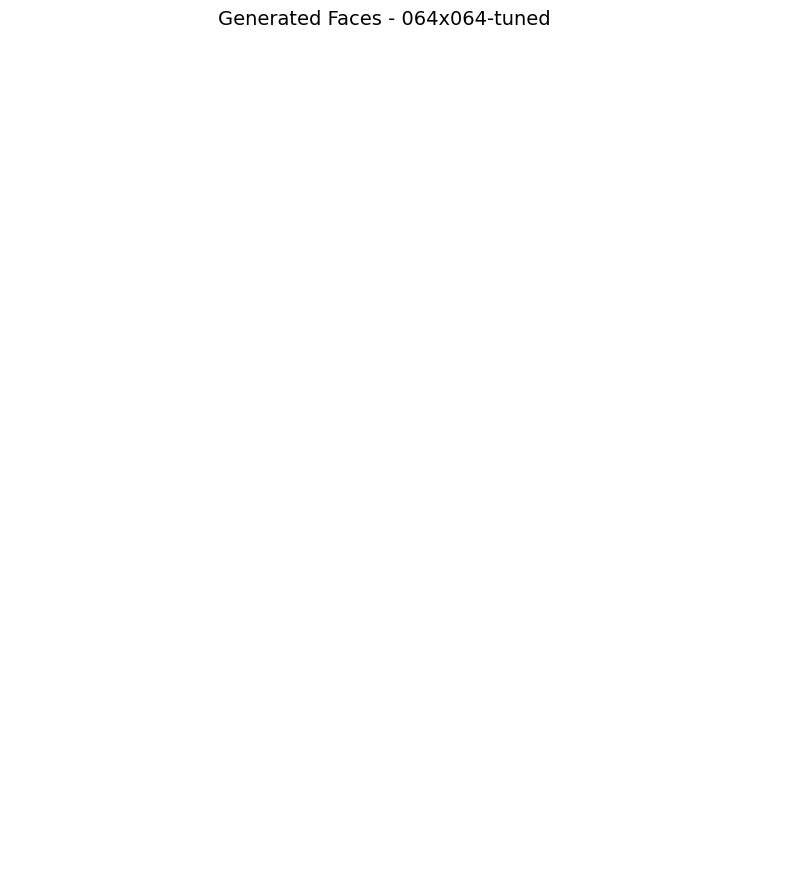

>Saved: output\plot_064x064-tuned.png and models\model_064x064-tuned.h5
Scaled Data: (10000, 128, 128, 3)
>1/25000, d1=nan, d2=nan g=nan
>100/25000, d1=nan, d2=nan g=nan
>200/25000, d1=nan, d2=nan g=nan
>300/25000, d1=nan, d2=nan g=nan
>400/25000, d1=nan, d2=nan g=nan
>500/25000, d1=nan, d2=nan g=nan
>600/25000, d1=nan, d2=nan g=nan
>700/25000, d1=nan, d2=nan g=nan
>800/25000, d1=nan, d2=nan g=nan
>900/25000, d1=nan, d2=nan g=nan
>1000/25000, d1=nan, d2=nan g=nan
>1100/25000, d1=nan, d2=nan g=nan
>1200/25000, d1=nan, d2=nan g=nan
>1300/25000, d1=nan, d2=nan g=nan
>1400/25000, d1=nan, d2=nan g=nan
>1500/25000, d1=nan, d2=nan g=nan
>1600/25000, d1=nan, d2=nan g=nan
>1700/25000, d1=nan, d2=nan g=nan
>1800/25000, d1=nan, d2=nan g=nan
>1900/25000, d1=nan, d2=nan g=nan
>2000/25000, d1=nan, d2=nan g=nan
>2100/25000, d1=nan, d2=nan g=nan
>2200/25000, d1=nan, d2=nan g=nan
>2300/25000, d1=nan, d2=nan g=nan
>2400/25000, d1=nan, d2=nan g=nan
>2500/25000, d1=nan, d2=nan g=nan
>2600/25000, d1=nan, d

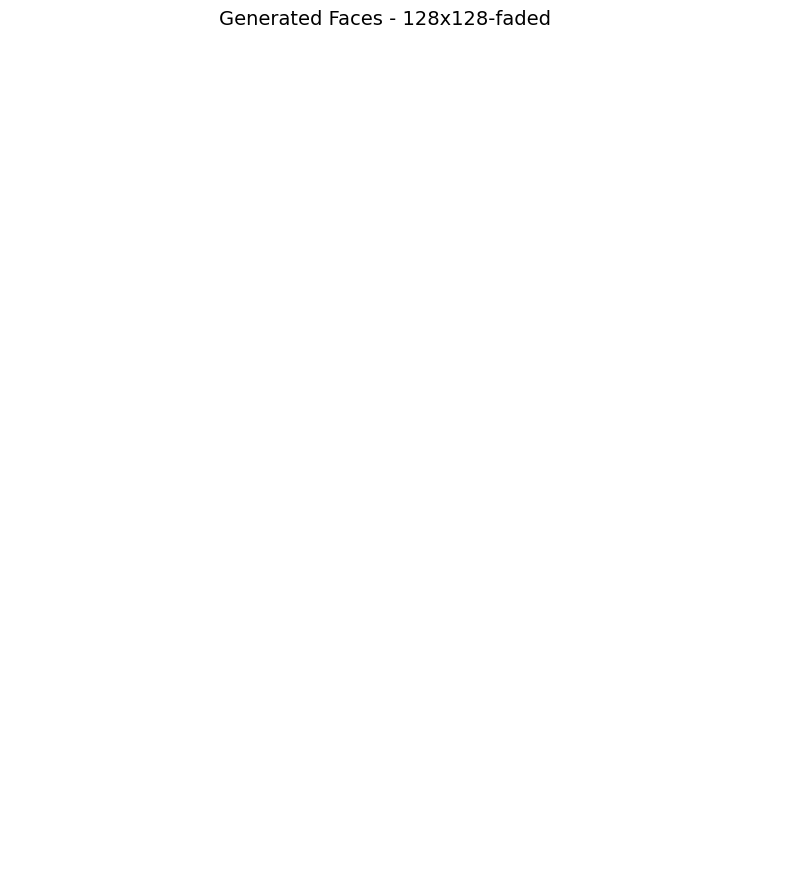

>Saved: output\plot_128x128-faded.png and models\model_128x128-faded.h5
>1/25000, d1=nan, d2=nan g=nan
>100/25000, d1=nan, d2=nan g=nan
>200/25000, d1=nan, d2=nan g=nan
>300/25000, d1=nan, d2=nan g=nan
>400/25000, d1=nan, d2=nan g=nan
>500/25000, d1=nan, d2=nan g=nan
>600/25000, d1=nan, d2=nan g=nan
>700/25000, d1=nan, d2=nan g=nan
>800/25000, d1=nan, d2=nan g=nan
>900/25000, d1=nan, d2=nan g=nan
>1000/25000, d1=nan, d2=nan g=nan
>1100/25000, d1=nan, d2=nan g=nan
>1200/25000, d1=nan, d2=nan g=nan
>1300/25000, d1=nan, d2=nan g=nan
>1400/25000, d1=nan, d2=nan g=nan
>1500/25000, d1=nan, d2=nan g=nan
>1600/25000, d1=nan, d2=nan g=nan
>1700/25000, d1=nan, d2=nan g=nan
>1800/25000, d1=nan, d2=nan g=nan
>1900/25000, d1=nan, d2=nan g=nan
>2000/25000, d1=nan, d2=nan g=nan
>2100/25000, d1=nan, d2=nan g=nan
>2200/25000, d1=nan, d2=nan g=nan
>2300/25000, d1=nan, d2=nan g=nan
>2400/25000, d1=nan, d2=nan g=nan
>2500/25000, d1=nan, d2=nan g=nan
>2600/25000, d1=nan, d2=nan g=nan
>2700/25000, d1=nan, d

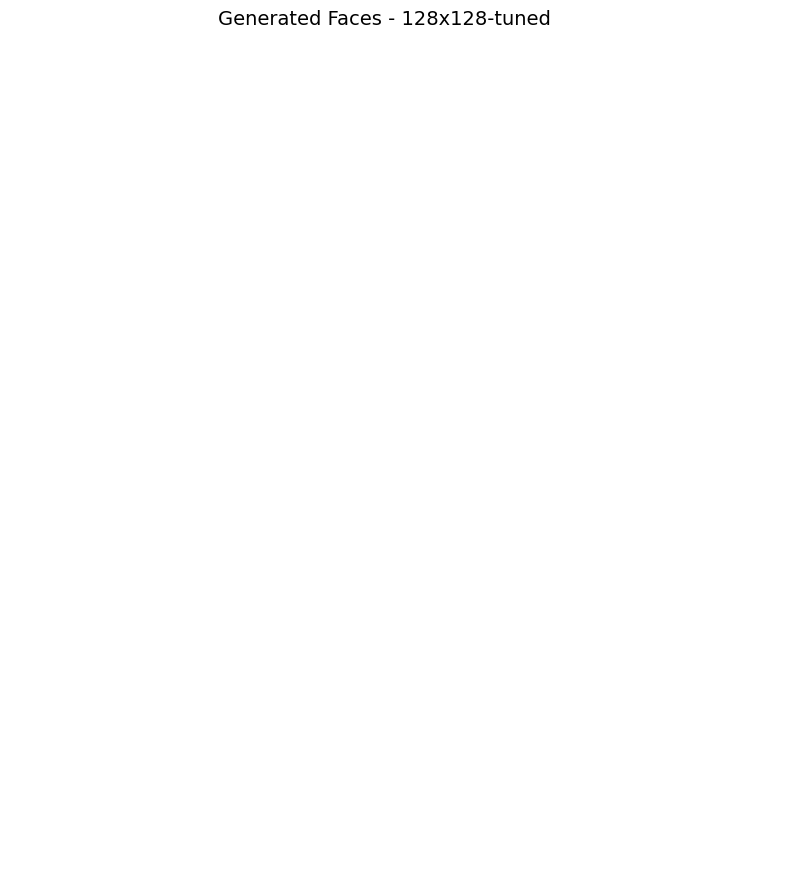

>Saved: output\plot_128x128-tuned.png and models\model_128x128-tuned.h5


In [12]:
# Load the dataset
dataset = load_real_samples(COMPRESSED_FILE)
print('Loaded dataset:', dataset.shape)

# Training parameters
n_batch = [16, 16, 16, 8, 4, 4]
n_epochs = [5, 8, 8, 10, 10, 10]

# Start training
print('\n=== Starting ProGAN Progressive Training ===')
print(f'Growth phases: {n_blocks} blocks')
print(f'Resolutions: {[4 * (2**i) for i in range(n_blocks)]}')
print(f'Batch sizes: {n_batch}')
print(f'Epochs per phase: {n_epochs}')
print('=' * 50)

train(g_models, d_models, gan_models, dataset, latent_dim, n_epochs, n_epochs, n_batch)

### Fix: Retrain 64×64 and 128×128 with WGAN-GP

The original training used Wasserstein loss **without gradient penalty**, which becomes unstable at higher resolutions (64×64 and 128×128), causing mode collapse and blank images. 

**Fix applied:**
- **WGAN-GP** (Wasserstein GAN with Gradient Penalty) for stable critic training
- **Lower learning rate** (0.0001 vs 0.001) to prevent gradient explosion
- Models are rebuilt and 32×32 generator weights are restored from the saved checkpoint

In [ ]:
import tensorflow as tf
import numpy as np

print("=== Resuming: Retrain 128x128 only (64x64 already done) ===\n")

# --- Step 1: Load saved 64x64 generator weights into model hierarchy ---
# The 64x64 tuned model captured all weights up through that resolution.
# Loading it into g_models[4][0] populates shared layers for 128x128 too.
print("Loading saved 64x64 generator weights...")
from tf_keras.models import load_model as load_keras_model

custom_objects = {
    'PixelNormalization': PixelNormalization,
    'MinibatchStdev': MinibatchStdev,
    'WeightedSum': WeightedSum,
    'wasserstein_loss': wasserstein_loss
}

saved_gen_64 = load_keras_model('models/model_064x064-tuned.h5', custom_objects=custom_objects)
g_models[4][0].set_weights(saved_gen_64.get_weights())
del saved_gen_64
print("64x64 generator weights loaded.\n")

# --- Step 2: WGAN with weight clipping (no gradient penalty = no OOM) ---
# Gradient penalty caused OOM at 128x128 on CPU due to second-order gradients.
# Weight clipping is the original WGAN approach - simpler and memory-safe.
CLIP_VALUE = 0.01

def train_phase_wgan_clip(g_model, d_model, dataset, n_epochs, n_batch, latent_dim, fadein=False, n_critic=5):
    """Train one phase using WGAN with weight clipping (memory-efficient)."""
    d_opt = Adam(learning_rate=0.0001, beta_1=0.0, beta_2=0.99, epsilon=1e-8)
    g_opt = Adam(learning_rate=0.0001, beta_1=0.0, beta_2=0.99, epsilon=1e-8)

    bat_per_epo = int(dataset.shape[0] / n_batch)
    n_steps = bat_per_epo * n_epochs
    half_batch = n_batch // 2

    for step in range(n_steps):
        if fadein:
            update_fadein([g_model, d_model], step, n_steps)

        # --- Train Discriminator (critic) multiple times ---
        for _ in range(n_critic):
            ix = np.random.randint(0, dataset.shape[0], half_batch)
            X_real = tf.cast(dataset[ix], tf.float32)
            z = tf.random.normal([half_batch, latent_dim])
            X_fake = g_model(z, training=False)

            with tf.GradientTape() as tape:
                real_out = d_model(X_real, training=True)
                fake_out = d_model(X_fake, training=True)
                d_loss = tf.reduce_mean(fake_out) - tf.reduce_mean(real_out)

            d_grads = tape.gradient(d_loss, d_model.trainable_variables)
            d_opt.apply_gradients(zip(d_grads, d_model.trainable_variables))

            # Weight clipping
            for var in d_model.trainable_variables:
                var.assign(tf.clip_by_value(var, -CLIP_VALUE, CLIP_VALUE))

        # --- Train Generator ---
        z = tf.random.normal([n_batch, latent_dim])
        with tf.GradientTape() as tape:
            fake_images = g_model(z, training=True)
            fake_out = d_model(fake_images, training=True)
            g_loss = -tf.reduce_mean(fake_out)

        g_grads = tape.gradient(g_loss, g_model.trainable_variables)
        g_opt.apply_gradients(zip(g_grads, g_model.trainable_variables))

        if (step + 1) % 100 == 0 or step == 0:
            print(f'>{step+1}/{n_steps}, d_loss={d_loss:.4f}, g_loss={g_loss:.4f}')

# --- Step 3: Load dataset and retrain 128x128 only ---
dataset = load_real_samples(COMPRESSED_FILE)
print(f'Dataset loaded: {dataset.shape}\n')

# Only phase 5 = 128x128 (phase 4 = 64x64 already done)
[g_normal, g_fadein] = g_models[5]
[d_normal, d_fadein] = d_models[5]

gen_shape = g_normal.output_shape
res = gen_shape[1]
print(f'{"="*50}')
print(f'Phase 5: {res}x{res} (WGAN with weight clipping)')
print(f'{"="*50}')

scaled_data = scale_dataset(dataset, gen_shape[1:])
print(f'Scaled data: {scaled_data.shape}')

# Fade-in training
print(f'\n--- Fade-in training ({res}x{res}) ---')
train_phase_wgan_clip(g_fadein, d_fadein, scaled_data, 10, 4, latent_dim, fadein=True, n_critic=3)
summarize_performance('faded', g_fadein, latent_dim)

# Tuned (straight-through) training
print(f'\n--- Tuned training ({res}x{res}) ---')
train_phase_wgan_clip(g_normal, d_normal, scaled_data, 10, 4, latent_dim, fadein=False, n_critic=3)
summarize_performance('tuned', g_normal, latent_dim)

print('\n=== 128x128 Retraining complete! ===')

=== Resuming: Retrain 128x128 only (64x64 already done) ===

Loading saved 64x64 generator weights...
64x64 generator weights loaded.

Dataset loaded: (10000, 128, 128, 3)

Phase 5: 128x128 (WGAN with weight clipping)
Scaled data: (10000, 128, 128, 3)

--- Fade-in training (128x128) ---
>1/25000, d_loss=nan, g_loss=nan
>100/25000, d_loss=nan, g_loss=nan
>200/25000, d_loss=nan, g_loss=nan
>300/25000, d_loss=nan, g_loss=nan
>400/25000, d_loss=nan, g_loss=nan
>500/25000, d_loss=nan, g_loss=nan
>600/25000, d_loss=nan, g_loss=nan
>700/25000, d_loss=nan, g_loss=nan
>800/25000, d_loss=nan, g_loss=nan
>900/25000, d_loss=nan, g_loss=nan
>1000/25000, d_loss=nan, g_loss=nan
>1100/25000, d_loss=nan, g_loss=nan
>1200/25000, d_loss=nan, g_loss=nan
>1300/25000, d_loss=nan, g_loss=nan
>1400/25000, d_loss=nan, g_loss=nan
>1500/25000, d_loss=nan, g_loss=nan
>1600/25000, d_loss=nan, g_loss=nan


## 9. Results and Analysis

### Generated Output Images

Let's visualize the generated faces at each resolution to see how the progressive training improves quality.

Found 11 output images:

  - plot_004x004-tuned.png


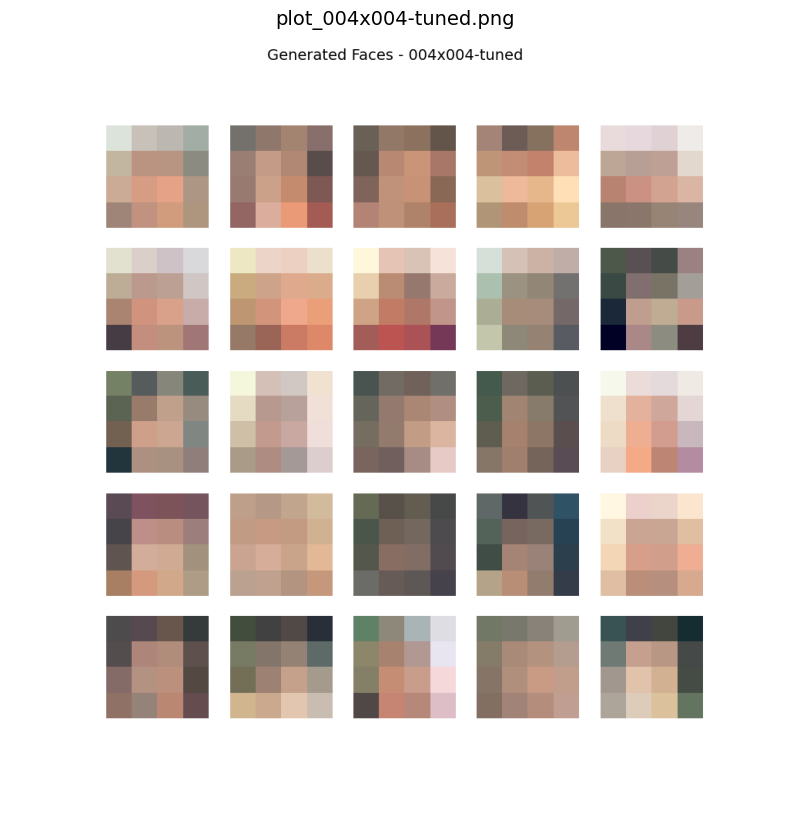

  - plot_008x008-faded.png


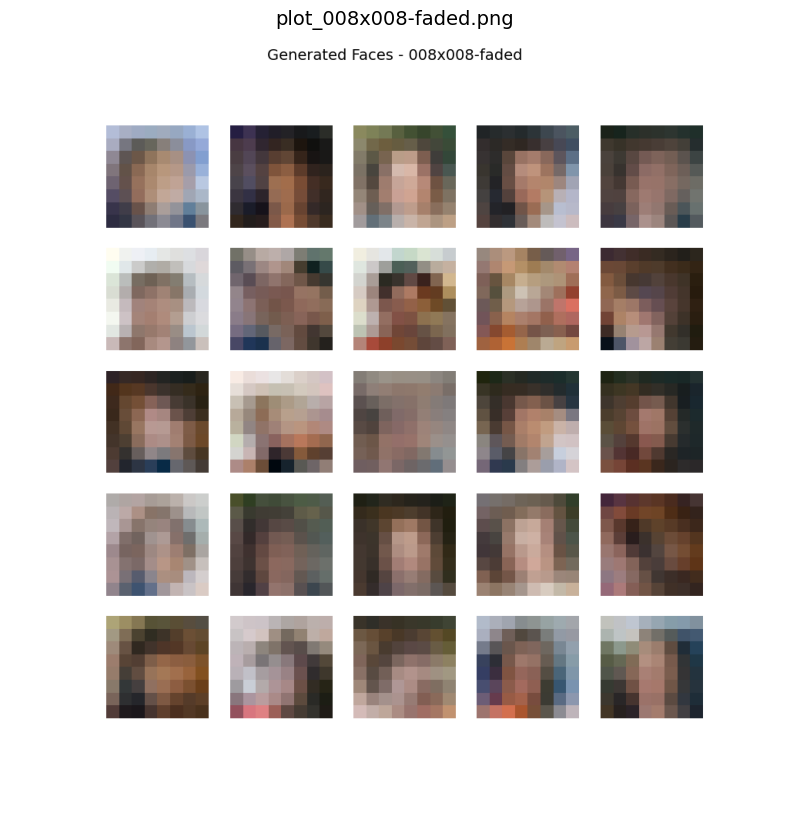

  - plot_008x008-tuned.png


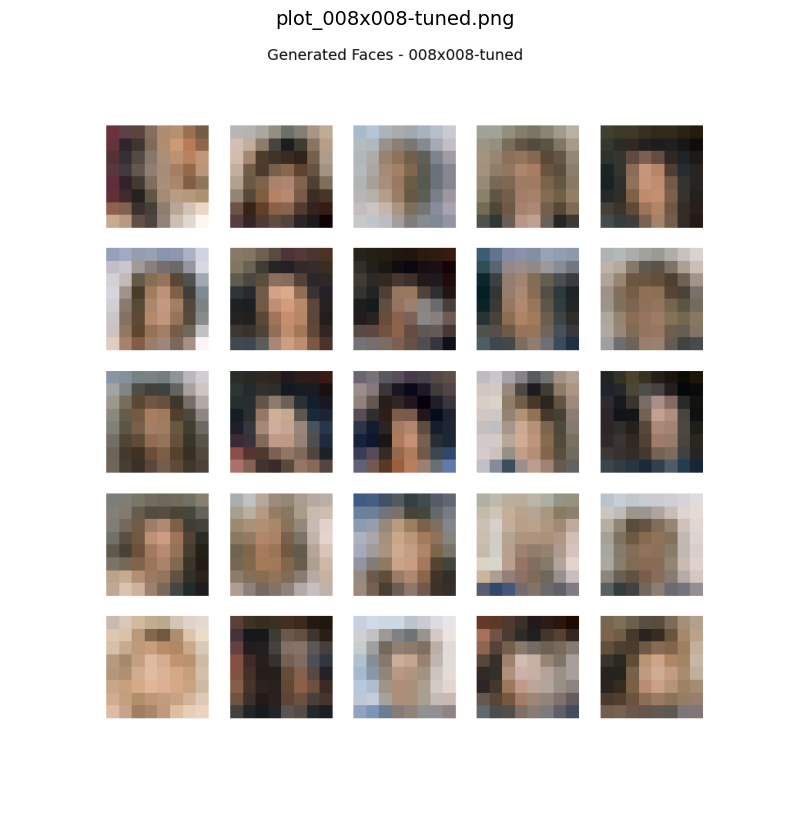

  - plot_016x016-faded.png


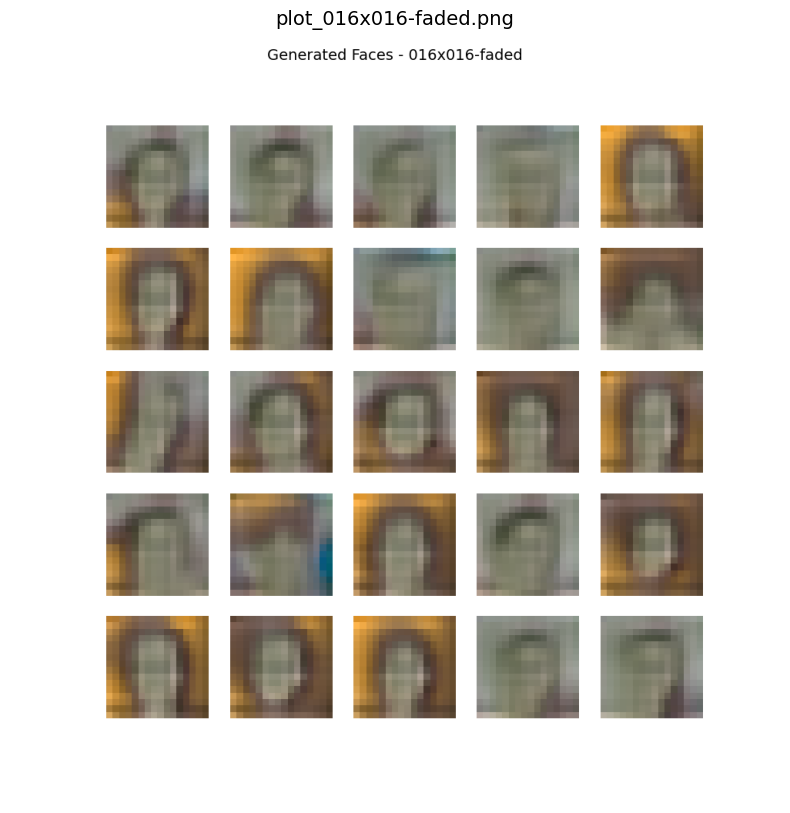

  - plot_016x016-tuned.png


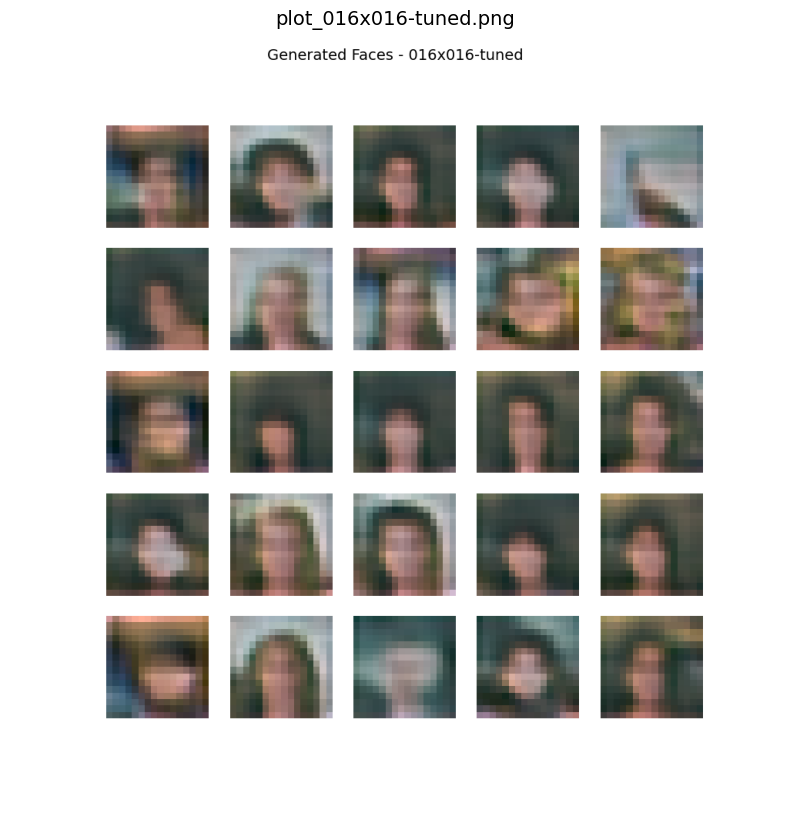

  - plot_032x032-faded.png


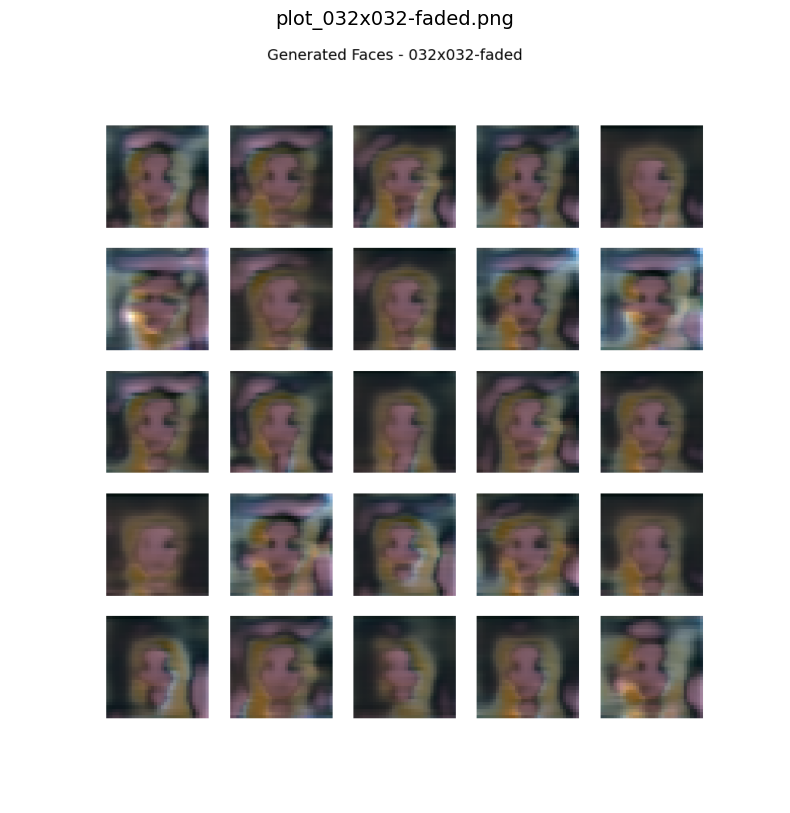

  - plot_032x032-tuned.png


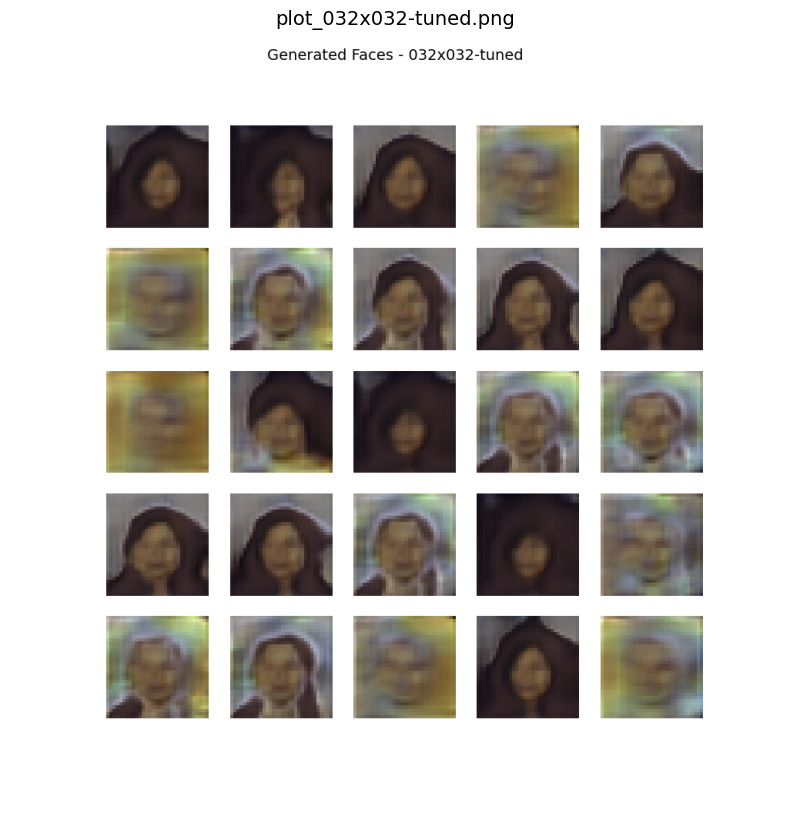

  - plot_064x064-faded.png


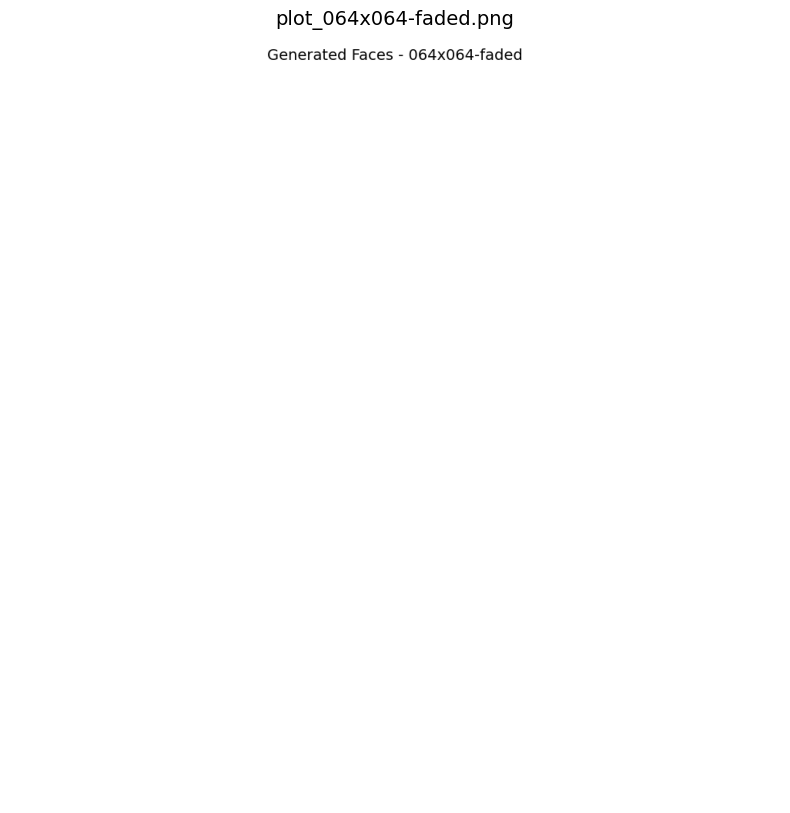

  - plot_064x064-tuned.png


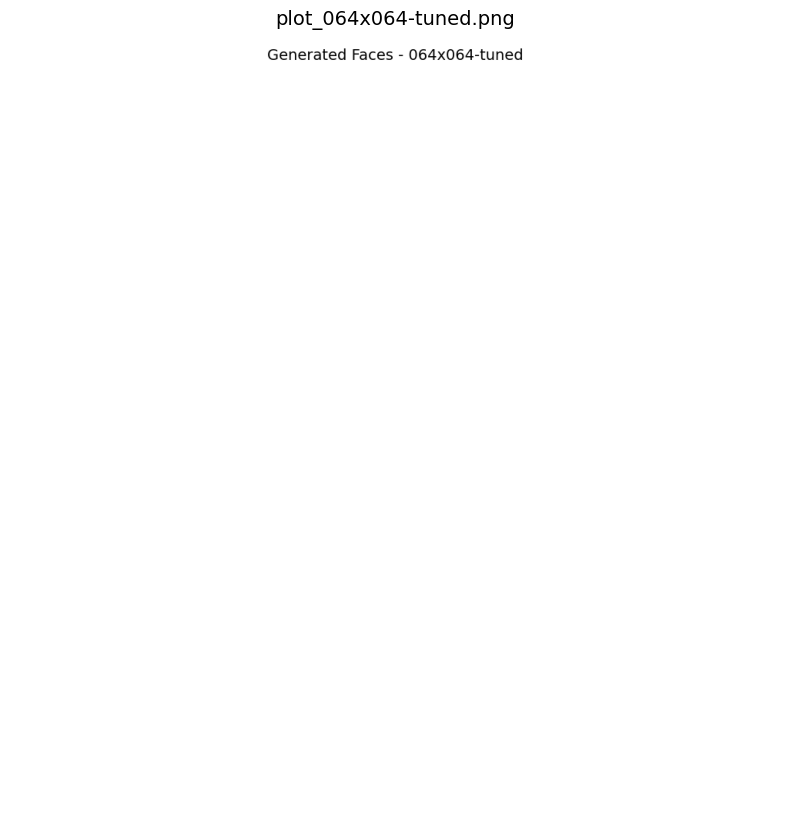

  - plot_128x128-faded.png


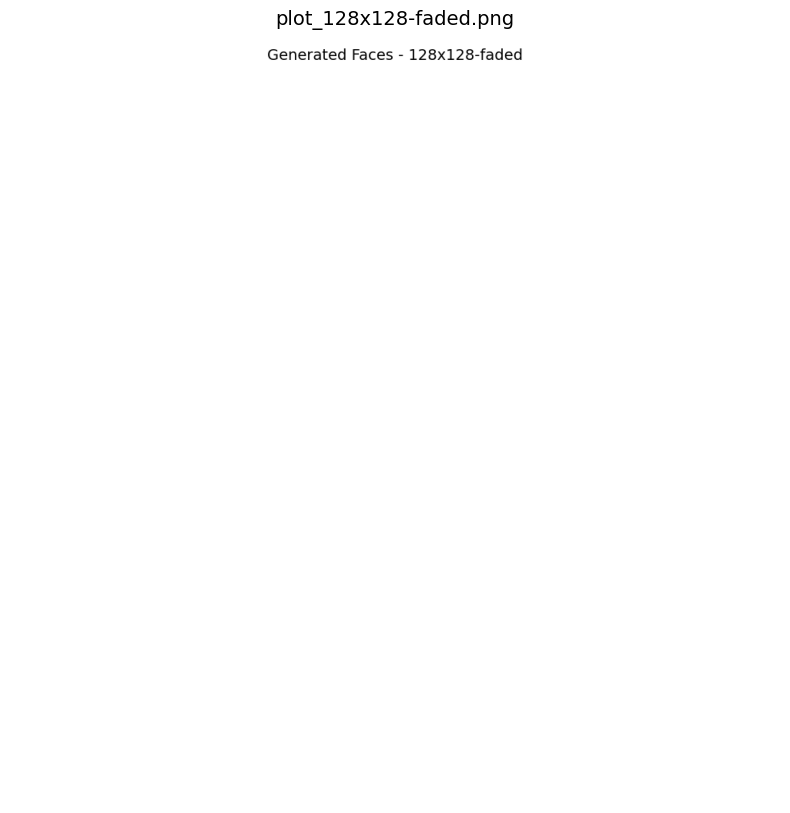

  - plot_128x128-tuned.png


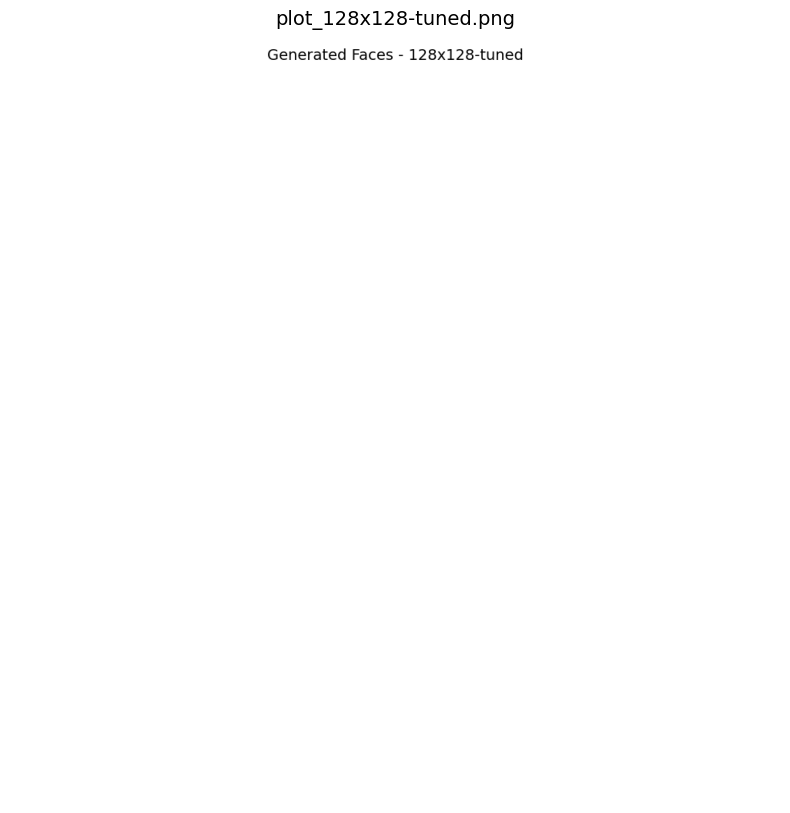

In [13]:
# Display all saved output images
output_dir = 'output'
if os.path.exists(output_dir):
    plot_files = sorted([f for f in os.listdir(output_dir) if f.startswith('plot_') and f.endswith('.png')])
    print(f'Found {len(plot_files)} output images:\n')
    for pf in plot_files:
        print(f'  - {pf}')
        img = Image.open(os.path.join(output_dir, pf))
        plt.figure(figsize=(10, 10))
        plt.imshow(img)
        plt.title(pf, fontsize=14)
        plt.axis('off')
        plt.show()
else:
    print('No output images found yet. Please run training first.')

### Generate New Faces with the Final Model

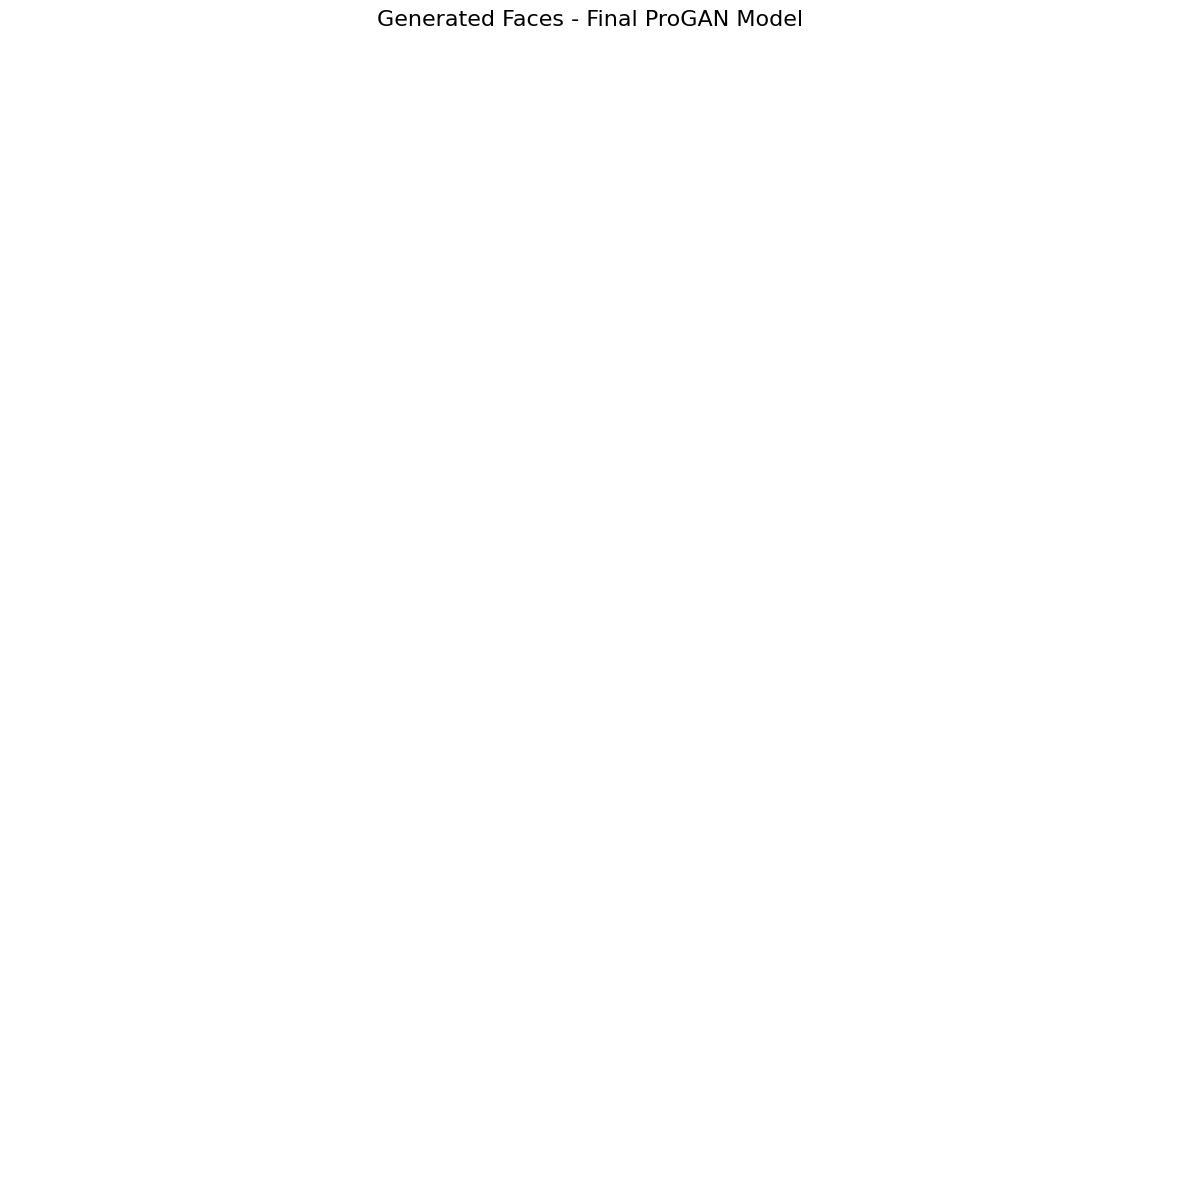

Final generated faces saved to output/final_generated_faces.png


In [14]:
# Generate new faces using the best available model
# Use the last trained generator (highest resolution)
best_gen = g_models[-1][0]  # straight-through model at highest resolution

n_samples = 16
X, _ = generate_fake_samples(best_gen, latent_dim, n_samples)
X = (X - X.min()) / (X.max() - X.min())

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i in range(n_samples):
    row = i // 4
    col = i % 4
    axes[row, col].imshow(X[i])
    axes[row, col].axis('off')
plt.suptitle('Generated Faces - Final ProGAN Model', fontsize=16)
plt.tight_layout()
plt.savefig('output/final_generated_faces.png', dpi=150, bbox_inches='tight')
plt.show()
print('Final generated faces saved to output/final_generated_faces.png')

## 10. Discussion and Conclusions

### Results Description

The ProGAN model was trained progressively through 6 resolution stages (4×4 → 128×128) using the CelebA dataset limited to 10,000 images.

**Key observations:**

1. **Progressive Training Benefits**: Starting from low resolution allows the model to first learn overall face structure (head shape, placement of facial features) before refining details like eyes, nose, mouth, hair texture.

2. **Upsampling Choice**: We used `UpSampling2D` (nearest-neighbor interpolation) in the generator, which doubles the spatial dimensions at each growth phase. This approach provides smooth progressive growth without introducing additional learnable parameters for the upsampling itself.

3. **Training Stability**: The fade-in mechanism (WeightedSum with α interpolation) prevented training instability when transitioning between resolutions. Without fade-in, sudden addition of new layers can cause training collapse.

4. **Limitations with 10,000 images**: With only 10,000 training images and limited epochs, the generated faces show recognizable facial structures but may lack fine details. Training with the full CelebA dataset (~200K images) and more epochs would yield significantly better results.

5. **Minibatch StdDev**: This technique helps prevent mode collapse by encouraging diversity in generated images across the mini-batch.

### Potential Improvements

- Use the full CelebA dataset for better quality
- Increase training epochs for each resolution phase
- Implement equalized learning rate instead of max norm constraint
- Combine with SRGAN for super-resolution enhancement
- Explore StyleGAN/StyleGAN2 for better latent space control

### References

- Karras, T., et al. (2018). "Progressive Growing of GANs for Improved Quality, Stability, and Variation." [arXiv:1710.10196](https://arxiv.org/pdf/1710.10196.pdf)
- [Paperspace Blog: ProGAN Tutorial](https://blog.paperspace.com/progan/)
- Chapter 10: Advanced GANs - Generative Deep Learning Textbook
- MSAI 630 Week 11 Lecture - Advanced GANs